Cell 1 — Install & Imports

In [17]:
!pip install tensorflow scikit-learn matplotlib --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

tf.random.set_seed(42)
np.random.seed(42)

Cell 2 — Synthetic 3-Variable Nonlinear Data

Same nonlinear regression function:
y=sin(x1​)+x22​+log(x32​+1)

In [18]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32).reshape(-1,1)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1000, 3)
Output shape: (1000, 1)


Cell 3 — Define TensorFlow High-Level Model (Sequential)

This is the simplest TensorFlow model using a stack of layers:

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(3,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)   # linear output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Cell 4 — Compile the Model

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Cell 5 — Train the Model

In [21]:
history = model.fit(X, y, epochs=500, batch_size=32, verbose=2)

Epoch 1/500
32/32 - 2s - 53ms/step - loss: 3.3188 - mse: 3.3188
Epoch 2/500
32/32 - 0s - 6ms/step - loss: 1.2295 - mse: 1.2295
Epoch 3/500
32/32 - 0s - 13ms/step - loss: 0.9631 - mse: 0.9631
Epoch 4/500
32/32 - 0s - 15ms/step - loss: 0.7138 - mse: 0.7138
Epoch 5/500
32/32 - 0s - 13ms/step - loss: 0.5324 - mse: 0.5324
Epoch 6/500
32/32 - 0s - 7ms/step - loss: 0.4089 - mse: 0.4089
Epoch 7/500
32/32 - 0s - 8ms/step - loss: 0.3308 - mse: 0.3308
Epoch 8/500
32/32 - 0s - 11ms/step - loss: 0.2767 - mse: 0.2767
Epoch 9/500
32/32 - 0s - 6ms/step - loss: 0.2353 - mse: 0.2353
Epoch 10/500
32/32 - 0s - 8ms/step - loss: 0.2025 - mse: 0.2025
Epoch 11/500
32/32 - 0s - 7ms/step - loss: 0.1766 - mse: 0.1766
Epoch 12/500
32/32 - 0s - 7ms/step - loss: 0.1565 - mse: 0.1565
Epoch 13/500
32/32 - 0s - 10ms/step - loss: 0.1398 - mse: 0.1398
Epoch 14/500
32/32 - 0s - 10ms/step - loss: 0.1254 - mse: 0.1254
Epoch 15/500
32/32 - 0s - 9ms/step - loss: 0.1115 - mse: 0.1115
Epoch 16/500
32/32 - 0s - 8ms/step - loss:

Cell 6 — Plot Training Loss

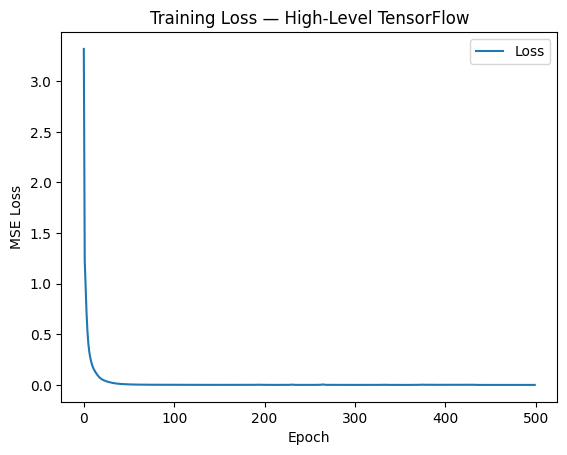

In [22]:
plt.plot(history.history["loss"], label="Loss")
plt.title("Training Loss — High-Level TensorFlow")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Cell 7 — True vs Predicted

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


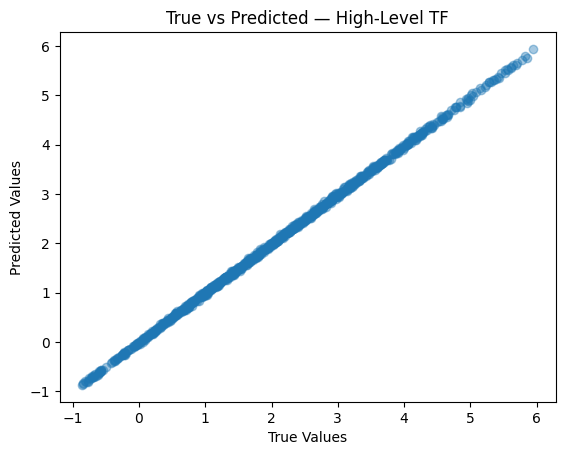

In [23]:
y_pred = model.predict(X)

plt.scatter(y, y_pred, alpha=0.4)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted — High-Level TF")
plt.show()

Cell 8 — 4D Visualization Using PCA

This plots 3 input variables after reducing them to 2, plus the output.

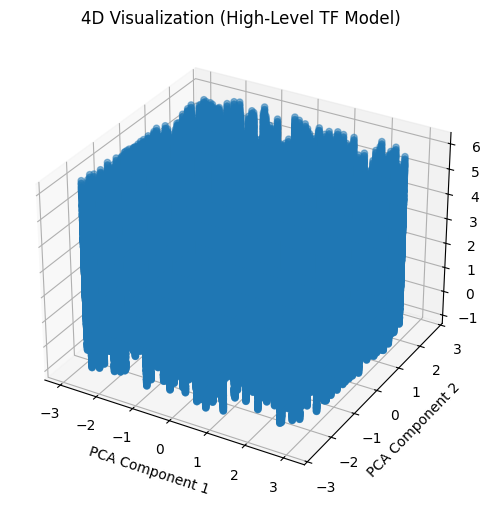

In [24]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Target Output")
plt.title("4D Visualization (High-Level TF Model)")
plt.show()